# Segmentazione K-Means del Comportamento degli Abbonati con PROC FASTCLUS

## Sintesi Esecutiva

Questo notebook segmenta una base sintetica di 100 abbonati mobili in cluster comportamentali usando `PROC FASTCLUS`, la procedura Base SAS per il clustering k-means. Sette variabili di utilizzo vengono standardizzate in z-score con `PROC STDIZE` in modo che le variabili di grande magnitudine (minuti voce, conteggio SMS) non dominino la distanza euclidea, quindi `PROC FASTCLUS` adatta tre cluster. La procedura riporta la deviazione RMS entro-cluster, un R-quadro complessivo e uno pseudo-F che quantificano quanto bene la segmentazione separa la base (qui un R-quadro complessivo di 0.575 e uno pseudo-F di 65.75), e scrive una tabella con punteggio con un'etichetta `CLUSTER` per ogni abbonato. Uniamo queste etichette ai dati sulla scala originale, profiliamo le persona e passiamo le assegnazioni all'attivazione a valle.

## Fonti dei Dati

| Dataset | Descrizione | Righe | Variabili chiave |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Istantanea mensile sintetica del comportamento per una base di abbonati di telecomunicazioni mobili, generata inline con `call streaminit` / `rand()`. Tre tipi di comportamento latenti (dati intensivi, centrato su voce, basso utilizzo) sono miscelati con rumore. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominale), `region` (nominale) |

# Segmentazione K-Means del Comportamento degli Abbonati

**Settore:** Telecomunicazioni &nbsp;|&nbsp; **Procedura:** `PROC FASTCLUS` (clustering k-means Base SAS)

Gli operatori mobili hanno abbonati il cui comportamento mensile -- appetito di dati, abitudini vocali, spesa e attrito nel supporto -- ricade in una manciata di pattern riconoscibili. Scoprire questi pattern permette all'azienda di personalizzare le azioni di retention, proporre i bundle giusti in upsell e acquisire clienti simili (look-alike). Questo notebook costruisce una segmentazione comportamentale end to end: genera un'istantanea realistica degli abbonati, standardizza le variabili, lascia che `PROC FASTCLUS` adatti i cluster, assegni un punteggio a ogni abbonato e profili i segmenti in persona utilizzabili. `PROC FASTCLUS` è progettata esattamente per questo compito di k-means disgiunto e scala a basi molto grandi passando sui dati invece di costruire una matrice di distanza completa.

## 1. Genera una base sintetica di abbonati

Simuliamo 100 abbonati estratti da tre archetipi comportamentali latenti -- **streamer a consumo intensivo di dati**, **tradizionalisti centrati sulla voce**, e clienti a **basso utilizzo** -- poi mescoliamo rumore in modo che i confini siano sfumati (come lo sono nella realtà). Ogni abbonato porta anche due attributi categoriali, `data_plan` e `region`, che usiamo più avanti per *profilare* i segmenti. Il seed rende i dati riproducibili.

In [1]:
/* -----------------------------------------------------------
   Istantanea sintetica di abbonati mobili (100 righe).
   Tre archetipi comportamentali latenti + rumore, più due
   attributi categoriali per il profiling dei segmenti.
   ----------------------------------------------------------- */
DATI subscribers;
    LUNGHEZZA data_plan $12 region $10;
    CHIAMARE streaminit(20260531);

    FARE subscriber_id = 100001 FINO_A 100100;

        /* archetipo latente: 1=dati intensivi, 2=voce, 3=basso utilizzo */
        u = rand('uniform');
        SE_COND      u < 0.38 ALLORA archetype = 1;
        ALTRIMENTI SE_COND u < 0.70 ALLORA archetype = 2;
        ALTRIMENTI                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        SE_COND archetype = 1 ALLORA FARE;             /* streamer a consumo intensivo di dati */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        FINE;
        ALTRIMENTI SE_COND archetype = 2 ALLORA FARE;        /* centrato sulla voce */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        FINE;
        ALTRIMENTI FARE;                              /* basso utilizzo */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        FINE;

        SE_COND planpick = 1 ALLORA data_plan = 'Prepagato';
        ALTRIMENTI SE_COND planpick = 2 ALLORA data_plan = 'Postpagato';
        ALTRIMENTI data_plan = 'Illimitato';

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        SE_COND region_pick = 1 ALLORA region = 'Nord';
        ALTRIMENTI SE_COND region_pick = 2 ALLORA region = 'Sud';
        ALTRIMENTI SE_COND region_pick = 3 ALLORA region = 'Est';
        ALTRIMENTI region = 'Ovest';

        /* arrotonda per una precisione di reportistica ordinata */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        USCITA;
    FINE;

    MANTENERE subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
ESEGUIRE;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Esamina le distribuzioni delle variabili

Prima del clustering, osserva la scala e la dispersione di ciascuna variabile comportamentale. Le unità di misura molto diverse -- gigabyte, minuti, dollari, conteggi -- sono esattamente il motivo per cui standardizziamo le variabili di intervallo prima del clustering; altrimenti variabili di grande magnitudine come `voice_minutes` dominerebbero la distanza euclidea che `PROC FASTCLUS` minimizza.

                                                  The MEANS Procedure

 Variable         Label                         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Anzianità (mesi)            100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Dati Mensili (GB)           100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Minuti Voce                 100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Conteggio SMS               100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Minuti Internazionali       100        45.1    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


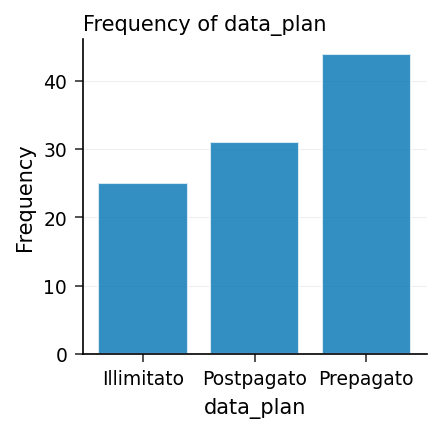

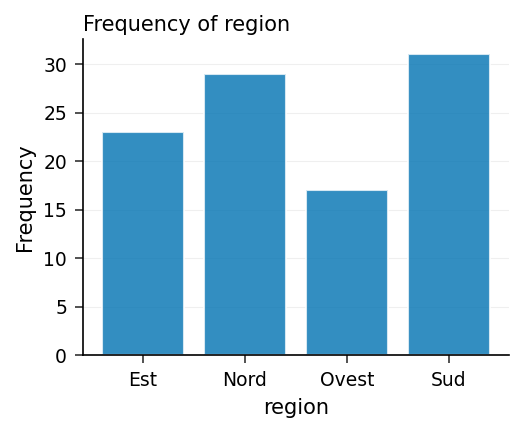

In [2]:
/* Statistiche riepilogative per le variabili di clustering */
PROCEDURA MEDIE DATI=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    VARIABILE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETICHETTA tenure_months='Anzianità (mesi)' monthly_data_gb='Dati Mensili (GB)'
          voice_minutes='Minuti Voce' sms_count='Conteggio SMS'
          intl_minutes='Minuti Internazionali' arpu='ARPU ($)'
          support_calls='Chiamate al Supporto';
ESEGUIRE;

/* Frequenza delle due variabili categoriali */
PROCEDURA FREQUENZE DATI=subscribers;
    TABLES data_plan region / nocum;
    ETICHETTA data_plan='Piano Tariffario' region='Regione';
ESEGUIRE;

## 3. Standardizza le variabili in z-score

`PROC FASTCLUS` minimizza la distanza euclidea, quindi una variabile misurata in centinaia di minuti sommergerebbe una variabile misurata in gigabyte a una cifra. `PROC STDIZE` con `METHOD=STD` riscala ogni variabile di intervallo a media 0 e deviazione standard 1, dando a ogni comportamento lo stesso peso nella distanza. Le colonne categoriali e l'identificativo passano invariati così da poter profilare i cluster sulla loro scala originale in seguito.

In [3]:
/* standardizza in z-score le variabili di intervallo; id e categoriali passano invariati */
PROCEDURA stdize DATI=subscribers out=subs_std METHOD=std;
    VARIABILE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
ESEGUIRE;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Adatta la segmentazione k-means

Adattiamo tre segmenti con `PROC FASTCLUS`. `MAXCLUSTERS=3` imposta *k*; `MAXITER=20` permette ai centri dei cluster di iterare fino alla convergenza. La procedura riporta un **Riepilogo dei Cluster** (dimensione e deviazione RMS entro-cluster per ciascun cluster), **Statistiche per le Variabili** (l'R-quadro contribuito da ciascuna variabile), un **R-quadro complessivo** e uno **pseudo-F** che misurano quanto nettamente i tre cluster separano la base, e le **Medie dei Cluster** sulla scala standardizzata. `OUT=scored` riscrive le righe di input con un'etichetta `CLUSTER` e la `DISTANCE` di ogni abbonato dal seme del proprio cluster.

In [4]:
/* adattamento k-means sulle variabili standardizzate: 3 segmenti. */
PROCEDURA FASTCLUS DATI=subs_std maxclusters=3 MAXITER=20 out=scored;
    VARIABILE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETICHETTA tenure_months='Anzianità (mesi)' monthly_data_gb='Dati Mensili (GB)'
          voice_minutes='Minuti Voce' sms_count='Conteggio SMS'
          intl_minutes='Minuti Internazionali' arpu='ARPU ($)'
          support_calls='Chiamate al Supporto';
ESEGUIRE;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Collega le etichette di segmento ai dati sulla scala originale

La tabella con il punteggio contiene le variabili standardizzate; per il profiling vogliamo che i cluster siano descritti in gigabyte, minuti e dollari reali. Uniamo l'etichetta `CLUSTER` alla tabella originale `subscribers` tramite `subscriber_id`, poi poniamo la prima domanda che il marketing si fa sempre: *quanto è grande ciascun segmento?*

                                                   The FREQ Procedure

Cluster    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


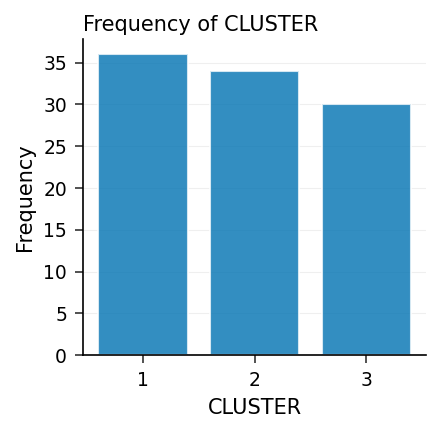

In [5]:
/* riporta l'etichetta di cluster ai dati sulla scala originale */
PROCEDURA ORDINARE DATI=scored(MANTENERE=subscriber_id CLUSTER distance) out=clus_assign;
    PER subscriber_id;
ESEGUIRE;
PROCEDURA ORDINARE DATI=subscribers out=subs_sorted;
    PER subscriber_id;
ESEGUIRE;
DATI profile;
    UNIRE subs_sorted clus_assign;
    PER subscriber_id;
    ETICHETTA CLUSTER='Cluster' distance='Distanza dal Centro';
ESEGUIRE;

/* Quanti abbonati sono finiti in ciascun segmento? */
PROCEDURA FREQUENZE DATI=profile;
    TABLES CLUSTER / nocum;
    ETICHETTA CLUSTER='Cluster';
ESEGUIRE;

## 6. Profila i segmenti

Gli ID dei cluster non hanno significato finché non descriviamo il *comportamento* all'interno di ciascuno. Calcolando la media delle variabili originali (non standardizzate) per `CLUSTER` emerge la persona dietro ogni segmento -- chi fa streaming, chi parla, chi usa a malapena la rete -- e il mix categoriale mostra quali piani e regioni si concentrano in ciascuno.

                                                  The MEANS Procedure

                                  Analysis Variable : tenure_months Anzianità (mesi)

        Cluster           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                                 Analysis Variable : monthly_data_gb Dati Mensili (GB)

        Cluster           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                     Analysis Variable : voice_minutes Minuti Voce

        Cluster           N Obs           Mean
        --------------------------------------
        1  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


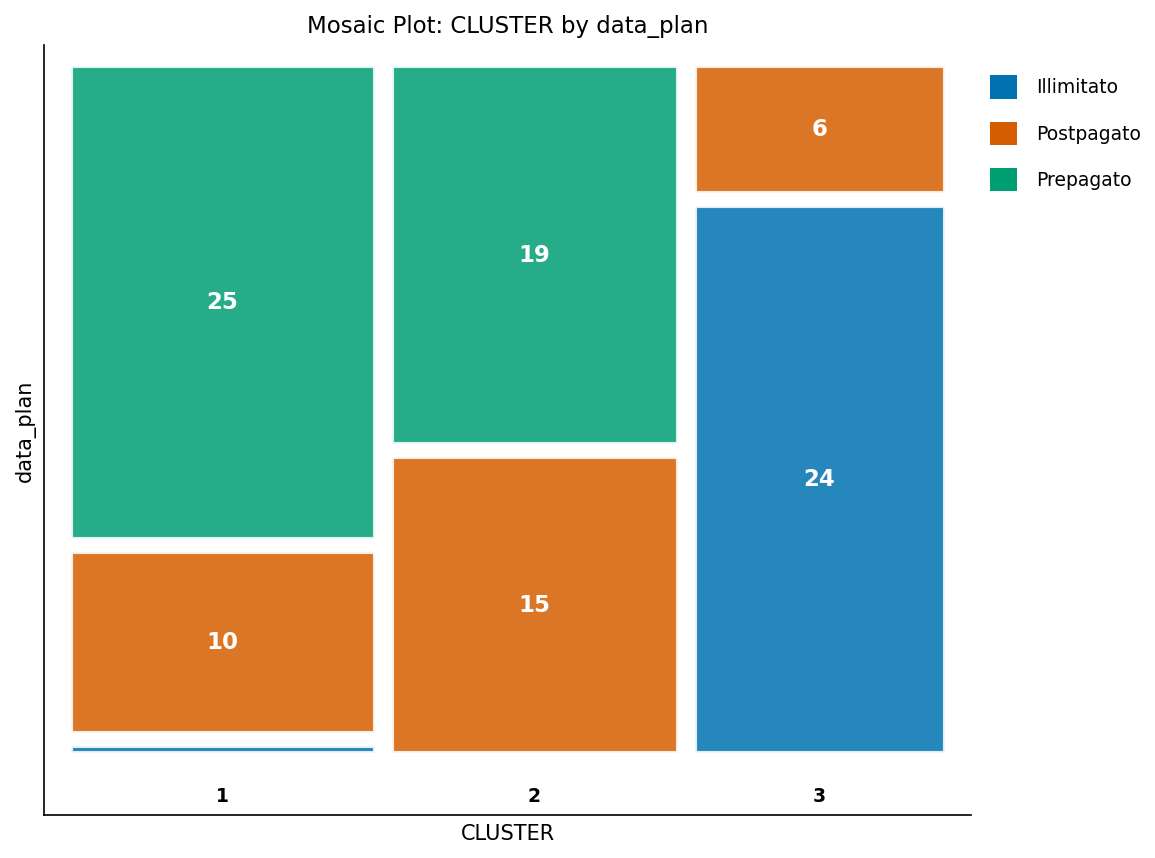

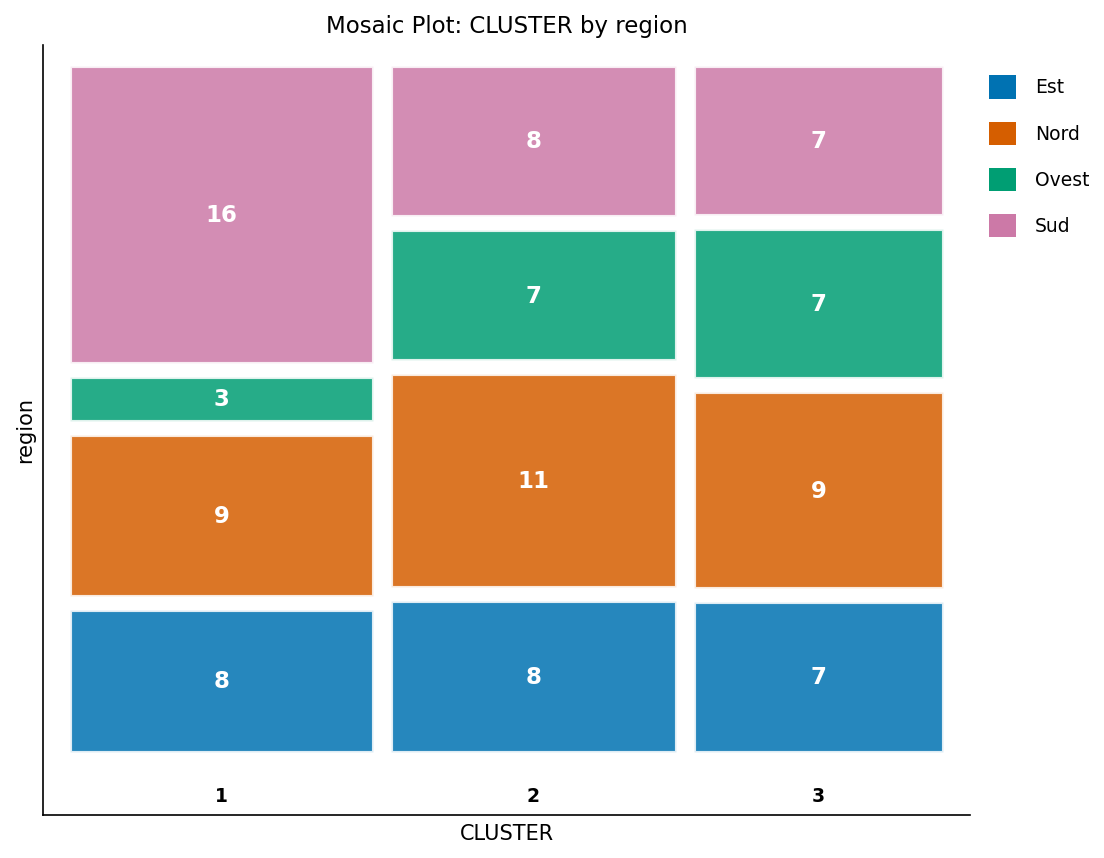

In [6]:
/* Profilo comportamentale: media di ogni variabile per segmento */
PROCEDURA MEDIE DATI=profile n mean maxdec=1;
    CLASSE CLUSTER;
    VARIABILE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETICHETTA CLUSTER='Cluster' tenure_months='Anzianità (mesi)' monthly_data_gb='Dati Mensili (GB)'
          voice_minutes='Minuti Voce' sms_count='Conteggio SMS'
          intl_minutes='Minuti Internazionali' arpu='ARPU ($)'
          support_calls='Chiamate al Supporto';
ESEGUIRE;

/* Mix categoriale all'interno di ogni segmento */
PROCEDURA FREQUENZE DATI=profile;
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
    ETICHETTA CLUSTER='Cluster' data_plan='Piano Tariffario' region='Regione';
ESEGUIRE;

## 7. Visualizza i segmenti

Un'immagine rende la segmentazione tangibile. Rappresentiamo l'appetito di dati rispetto all'uso vocale, colorato per segmento, e aggiungiamo un box plot dell'ARPU per segmento così la storia dei ricavi è evidente a colpo d'occhio.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


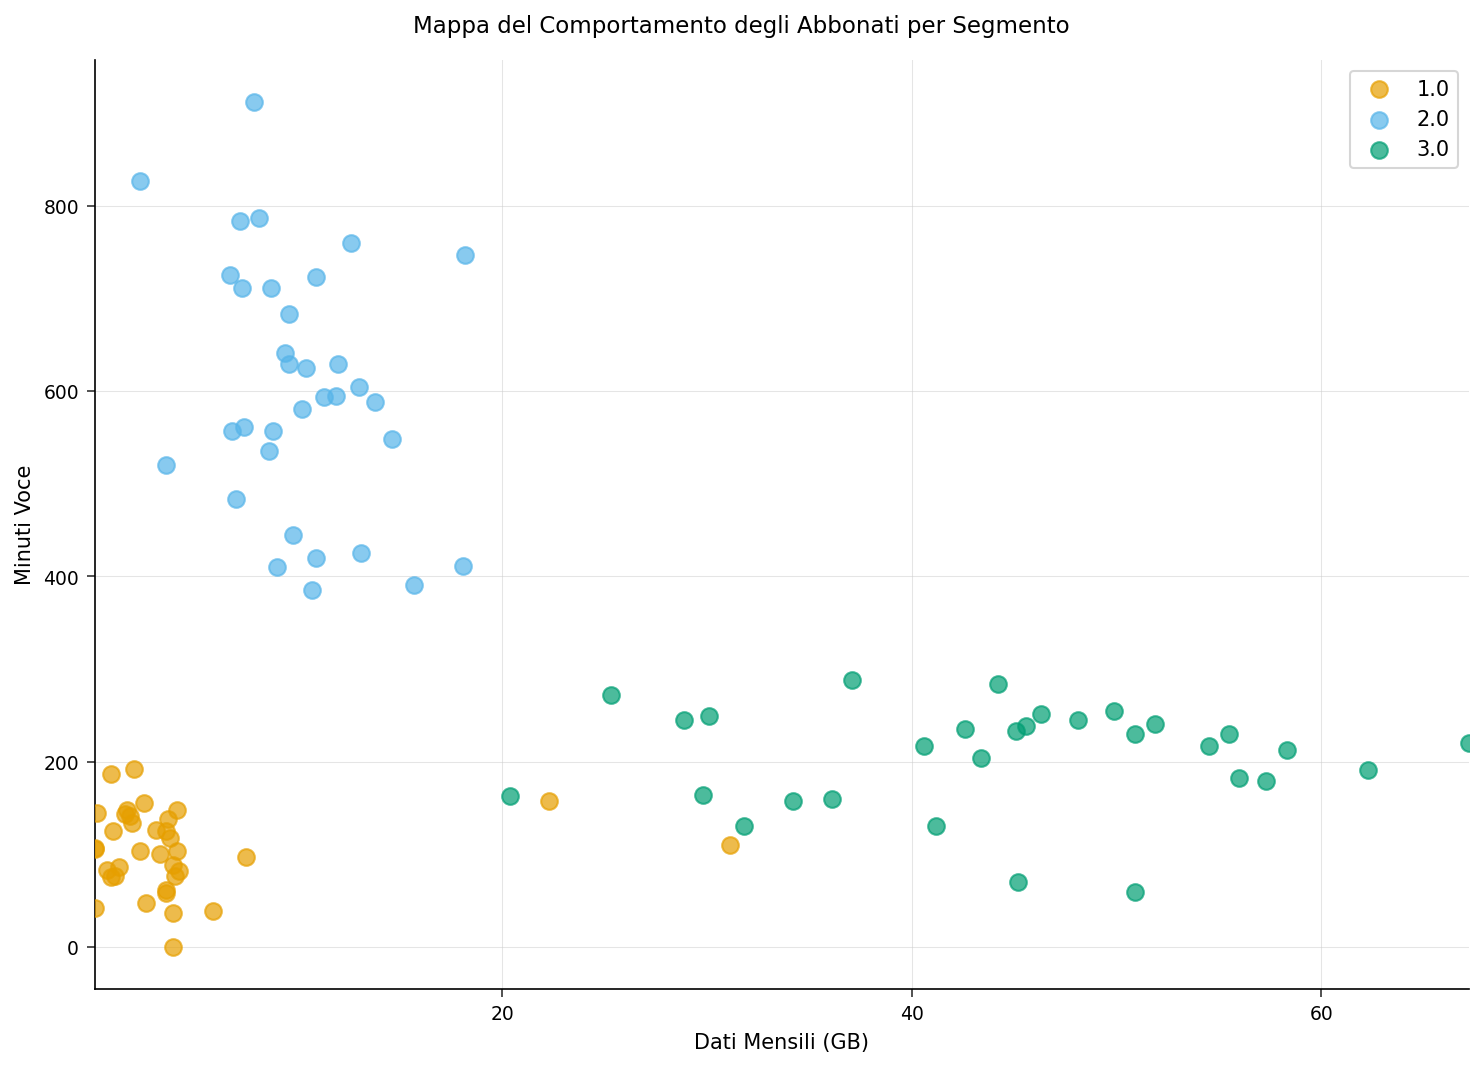

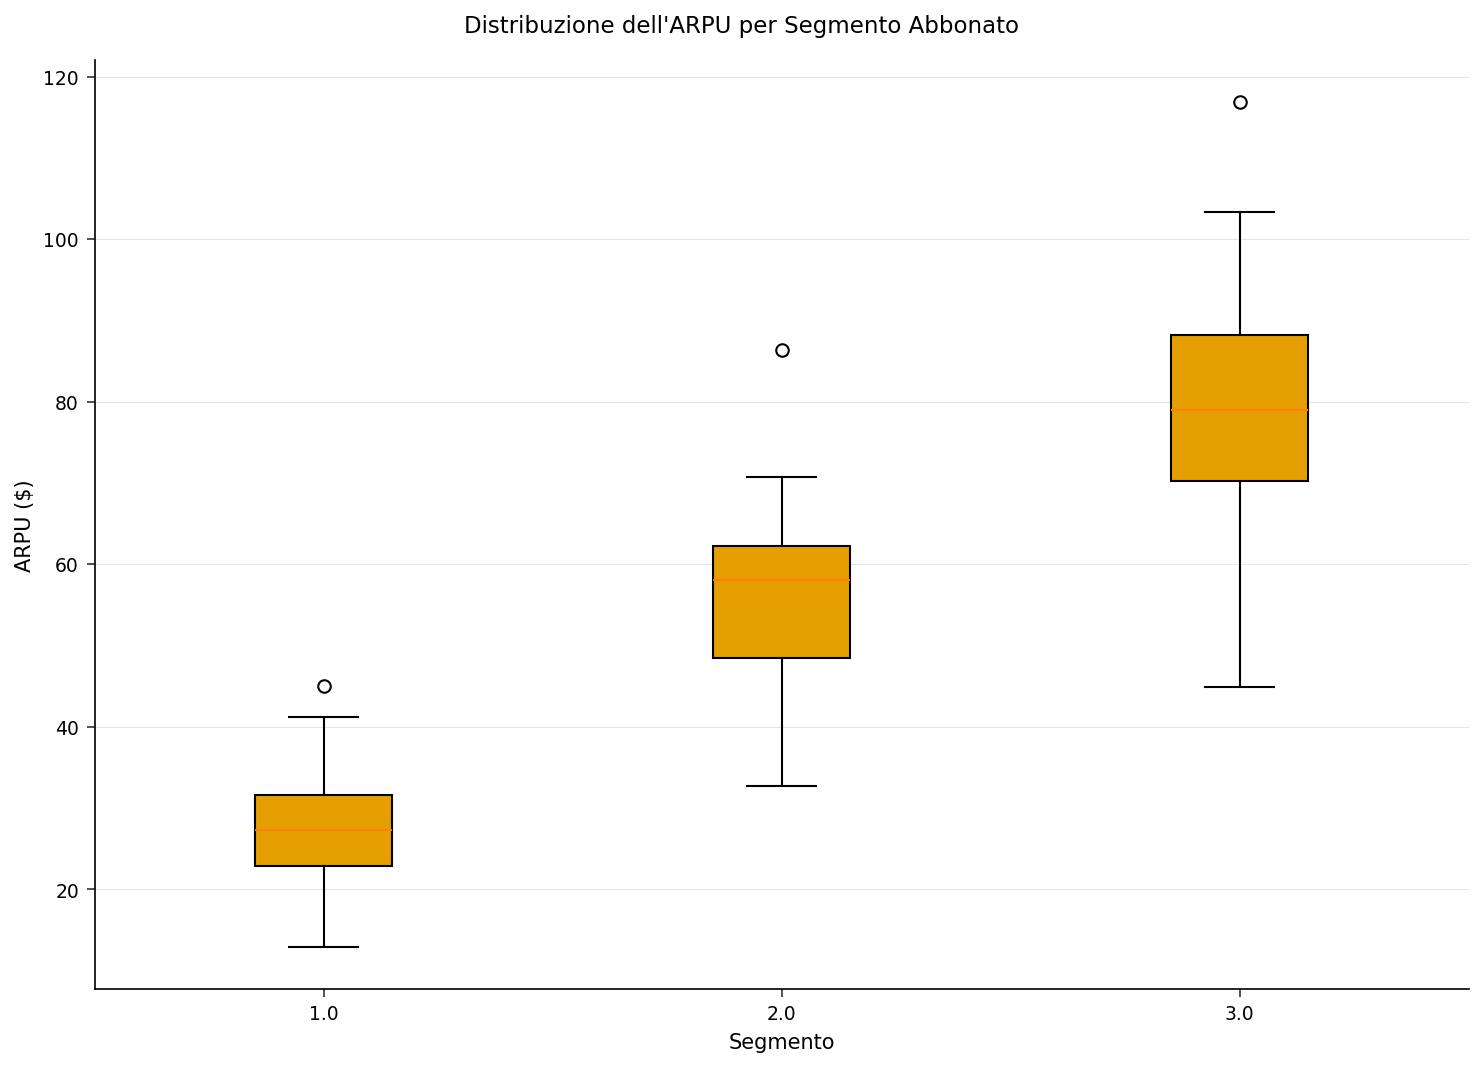

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Mappa comportamentale: dati vs. voce, colorata per segmento */
PROCEDURA SGPLOT DATI=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS ETICHETTA='Dati Mensili (GB)' grid;
    YAXIS ETICHETTA='Minuti Voce'       grid;
    TITOLO 'Mappa del Comportamento degli Abbonati per Segmento';
ESEGUIRE;

/* Distribuzione dei ricavi per segmento */
PROCEDURA SGPLOT DATI=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS ETICHETTA='Segmento';
    YAXIS ETICHETTA='ARPU ($)' grid;
    TITOLO "Distribuzione dell'ARPU per Segmento Abbonato";
ESEGUIRE;

## 8. Esporta i segmenti assegnati

Infine, passiamo le assegnazioni ai sistemi CRM e di campagna a valle. Manteniamo l'identificativo, l'etichetta di cluster e le variabili comportamentali principali.

In [8]:
/* Conserva le assegnazioni di segmento per l'attivazione */
DATI subscriber_segments;
    IMPOSTARE profile;
    MANTENERE subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
ESEGUIRE;

PROCEDURA STAMPARE DATI=subscriber_segments(obs=10) noobs ETICHETTA;
    ETICHETTA subscriber_id='ID Abbonato' CLUSTER='Cluster' tenure_months='Anzianità (mesi)'
          monthly_data_gb='Dati Mensili (GB)' voice_minutes='Minuti Voce'
          arpu='ARPU ($)' data_plan='Piano Tariffario' region='Regione';
    TITOLO 'Campione di Segmenti Abbonati Assegnati';
ESEGUIRE;

                                        Campione di Segmenti Abbonati Assegnati                                         

ID Abbonato  Cluster   Anzianità (mesi)  Dati Mensili (GB)  Minuti Voce  ARPU ($)  Piano Tariffario  Regione
     100001        1                 30                2.3          104        28  Prepagato         Sud
     100002        2                  8               10.2          581     57.78  Prepagato         Ovest
     100003        2                  8               10.7          385     55.66  Postpagato        Nord
     100004        2                 68                7.4          561     70.68  Prepagato         Nord
     100005        3                 18               45.6          239     63.85  Illimitato        Nord
     100006        3                 10               30.1          249     88.33  Illimitato        Est
     100007        1                 62                0.7           83     21.26  Prepagato         Sud
     100008        1         


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpretazione dei risultati

`PROC FASTCLUS` ha individuato tre segmenti puliti e ben separati. L'adattamento è solido: l'**R-quadro complessivo è 0.575** e lo **pseudo-F è 65.75**, il che significa che i tre cluster spiegano circa il 58% della variazione totale nelle variabili standardizzate. La separazione è guidata quasi interamente dai segnali comportamentali che ci interessano -- `voice_minutes` (R-quadro 0.858), `monthly_data_gb` (0.844) e `arpu` (0.771) trainano la segmentazione, mentre `tenure_months` (0.000) e `support_calls` (0.193) contribuiscono quasi a nulla, confermando che *come* un abbonato usa la rete -- non da quanto tempo è cliente -- definisce le persona.

I tre segmenti si mappano direttamente su persona pronte per il marketing, profilate qui sulla scala originale (non standardizzata):

| Segmento | n (quota) | Comportamento distintivo | Mix di piani | Persona | Azione consigliata |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Dati più alti: **44.4 GB/mese**, spesa più alta **$79.1 ARPU**, voce modesta (205 min) | 24/30 **Illimitato** | **Streamer a consumo intensivo di dati** | Proteggi e proponi upsell: livelli più veloci, bundle di contenuti, upgrade dispositivi |
| **2** | 34 (34%) | Voce più alta **603 min/mese**, **214 SMS**, **106 min internazionali**, spesa media **$55.9 ARPU** | Prepagato + Postpagato, **nessun Illimitato** | **Tradizionalisti centrati sulla voce** | Add-on internazionali, bundle famiglia/voce, premi fedeltà |
| **1** | 36 (36%) | Utilizzo più basso: **4.0 GB**, 104 min voce, spesa più bassa **$28.0 ARPU** | 25/36 **Prepagato** | **Basso utilizzo / leggero** | Piani su misura, incentivi ad addebito automatico, starter dati a basso costo per far crescere l'utilizzo |

Il mix di piani conferma la lettura comportamentale: il segmento a consumo intensivo di dati è in stragrande maggioranza su piani **Illimitato** (24 su 30), il segmento centrato sulla voce non ha **nessun** abbonato Illimitato, e il segmento a basso utilizzo è per lo più **Prepagato** (25 su 36). La regione, al contrario, è distribuita uniformemente tra tutti e tre i segmenti -- la geografia qui non è un fattore comportamentale, il che è di per sé un risultato utile per il targeting delle campagne.

**Perché `PROC FASTCLUS` è adatta a questo problema.** Esegue un k-means disgiunto passando sui dati invece di materializzare una matrice di distanza completa, quindi lo stesso programma che ha segmentato questi 100 abbonati scala a basi molto più grandi. Standardizzare prima con `PROC STDIZE` ha rimosso il bias di scala delle unità tra gigabyte, minuti e dollari, così che ogni comportamento ha contribuito in egual misura alla distanza euclidea; le diagnostiche R-quadro ci hanno poi detto *quali* variabili hanno realmente guidato la separazione. L'output con punteggio -- un'etichetta `CLUSTER` per ogni abbonato -- si inserisce direttamente nelle pipeline di attivazione, chiudendo il ciclo dal comportamento grezzo all'offerta mirata.

---

<div style="font-size:11px;color:#9e9e9e">Questo notebook è fornito solo a scopo dimostrativo. I dati sono sintetiche e i risultati non costituiscono consulenza aziendale.</div>